In [1]:
from loss_funktion.bout_info import BOUTHESELInfo
from pathlib import Path

hesel_path = Path.cwd().resolve().parent / "simulatorer/BOUT/BOUT-HESEL" / "data"
info = BOUTHESELInfo(hesel_path)


ImportError: cannot import name 'InnerBoundaryTargets' from 'loss_funktion.api.bout_struct' (/home/andreas_a/Desktop/Bachelorprojekt/SciML/loss_funktion/api/bout_struct.py)

interactive(children=(IntSlider(value=0, description='t_idx', max=308), Output()), _dom_classes=('widget-inter…

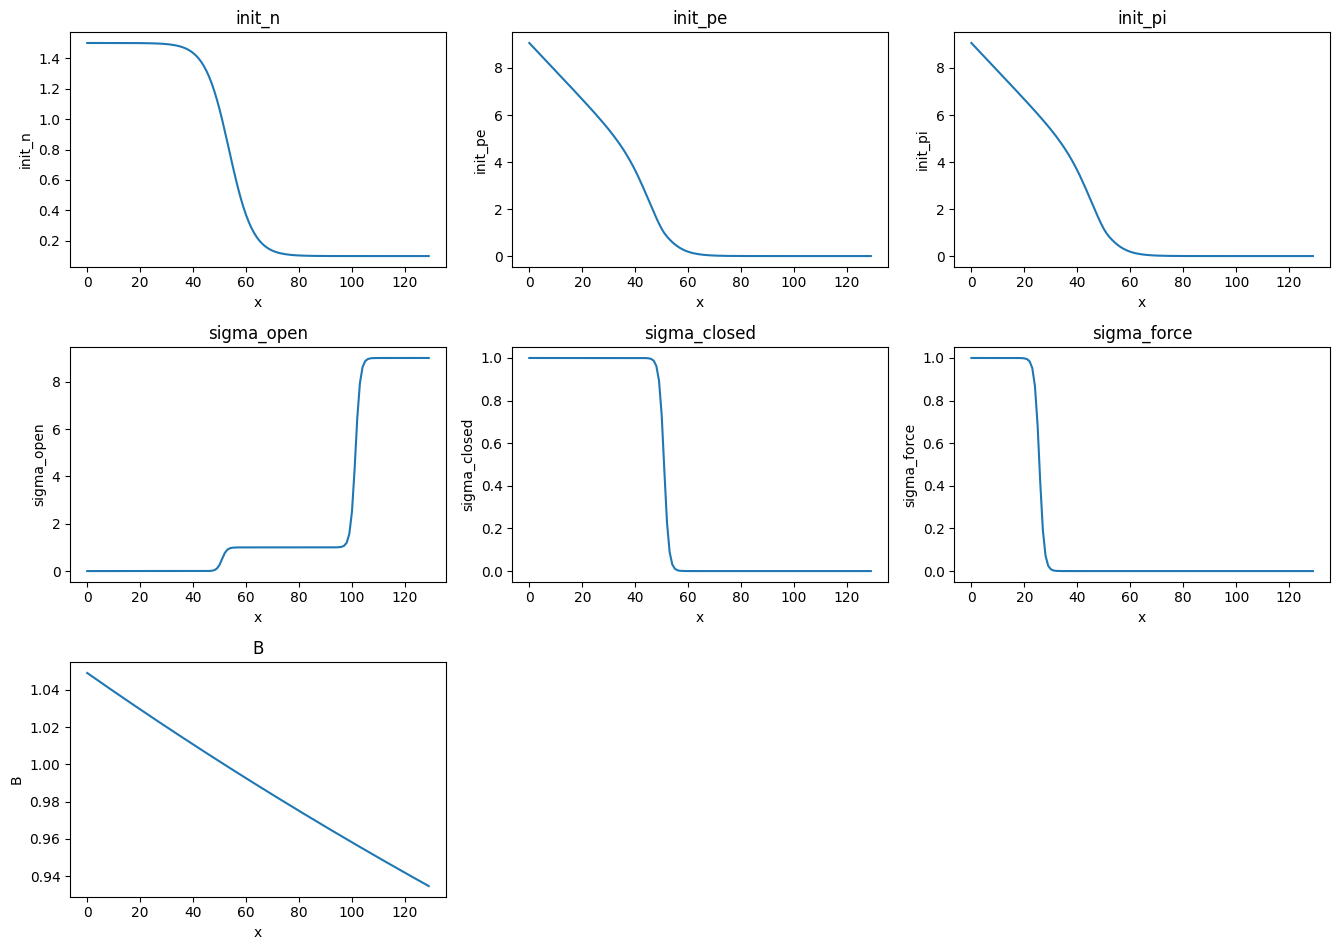

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

wanted_slider_vars = ["lnn", "lnpe", "lnpi", "vort", "phi"]
wanted_line_vars = ["init_n", "init_pe", "init_pi", "sigma_open", "sigma_closed", "sigma_force", "B"]

slider_vars = [
    name
    for name in wanted_slider_vars
    if name in info.data and np.asarray(info.data[name]).ndim >= 3
]

line_vars = [
    name
    for name in wanted_line_vars
    if name in info.data and np.asarray(info.data[name]).ndim == 1
]


def _time_image(name: str, t_idx: int):
    arr = np.asarray(info.data[name])
    t_idx = int(np.clip(t_idx, 0, arr.shape[0] - 1))
    return arr[t_idx], t_idx


def plot_slider_group(t_idx: int = 0):
    n = len(slider_vars)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, slider_vars):
        img, t_used = _time_image(name, t_idx)
        im = ax.imshow(img, aspect="auto", origin="lower", cmap="viridis")
        ax.set_title(f"{name} @ t={t_used}")
        ax.set_xlabel("z")
        ax.set_ylabel("x")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


if slider_vars:
    t_max = max(np.asarray(info.data[name]).shape[0] - 1 for name in slider_vars)
    interact(plot_slider_group, t_idx=IntSlider(min=0, max=t_max, step=1, value=0))


if line_vars:
    n = len(line_vars)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, line_vars):
        arr = np.asarray(info.data[name])
        ax.plot(arr)
        ax.set_title(name)
        ax.set_xlabel("x")
        ax.set_ylabel(name)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from ipywidgets import interact, IntSlider
from pathlib import Path

from utils.model import PINN

prediction_vars = ["lnn", "lnpe", "lnpi", "phi"]

def _activation_from_name(name: str):
    return getattr(torch.nn, name)

def _load_latest_model_from_checkpoint():
    candidate_dirs = [
        Path.cwd().resolve() / "data",
        Path.cwd().resolve().parent / "SciML" / "data",
    ]

    ckpt_dir = None
    for candidate_dir in candidate_dirs:
        if candidate_dir.exists():
            ckpt_dir = candidate_dir
            break

    if ckpt_dir is None:
        print("Fandt ikke en data-mappe med checkpoints.")
        return None, None, None

    checkpoints = [
        path
        for path in sorted(ckpt_dir.glob("trained_pinn_*.pt"), key=lambda p: p.stat().st_mtime)
        if path.stat().st_size > 0
    ]
    if not checkpoints:
        print(f"Ingen ikke-tomme checkpoints fundet i {ckpt_dir}.")
        return None, None, None

    ckpt_path = checkpoints[-1]
    checkpoint = torch.load(ckpt_path, map_location="cpu")

    serialized = checkpoint["nn_structure"]
    structure = {
        "input_size": int(serialized["input_size"]),
        "output_size": int(serialized["output_size"]),
        "output_names": tuple(serialized["output_names"]),
        "layers": [
            {
                "size": int(layer["size"]),
                "non_lin_foo": _activation_from_name(layer["non_lin_foo"]),
            }
            for layer in serialized["layers"]
        ],
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PINN(structure).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if checkpoint.get("output_scaling") is not None:
        model.set_output_scaling(checkpoint["output_scaling"])
    model.eval()
    print(f"Loaded checkpoint: {ckpt_path.name}")
    return model, device, ckpt_path


def _predict_model_fields(model, device, info_obj, t_idx: int):
    nt, nx, nz = np.asarray(info_obj.data["lnn"]).shape
    t_idx = int(np.clip(t_idx, 0, max(nt - 1, 0)))

    x_vals = torch.linspace(0.0, 1.0, nx, device=device)
    z_vals = torch.linspace(0.0, 1.0, nz, device=device)
    x_grid, z_grid = torch.meshgrid(x_vals, z_vals, indexing="ij")
    t_grid = torch.full_like(x_grid, float(t_idx))

    with torch.no_grad():
        prediction = model.predict_physical(
            x_grid.reshape(-1, 1),
            z_grid.reshape(-1, 1),
            t_grid.reshape(-1, 1),
        )

    return {
        name: prediction[name].reshape(nx, nz).detach().cpu().numpy()
        for name in prediction_vars
    }, t_idx


loaded_model = _load_latest_model_from_checkpoint()
if loaded_model[0] is not None:
    model, device, ckpt_path = loaded_model

    def _plot_prediction_group(t_idx: int = 0):
        predicted_fields, t_used = _predict_model_fields(model, device, info, t_idx)
        n = len(prediction_vars)
        cols = 2
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 3.8 * rows))
        axes = np.atleast_1d(axes).ravel()

        for ax, name in zip(axes, prediction_vars):
            img = predicted_fields[name]
            im = ax.imshow(img, aspect="auto", origin="lower", cmap="viridis")
            ax.set_title(f"{name} prediction @ t={t_used}")
            ax.set_xlabel("z")
            ax.set_ylabel("x")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        for ax in axes[n:]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    t_max = max(np.asarray(info.data[name]).shape[0] - 1 for name in prediction_vars)
    interact(_plot_prediction_group, t_idx=IntSlider(min=0, max=t_max, step=1, value=0))
else:
    print("Fandt ikke et gyldigt checkpoint.")

Loaded checkpoint: trained_pinn_2026-04-27_11-17-29.pt


NameError: name 'info' is not defined